In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Assignment1_mimic dataset.csv")

print(df.shape)

(65366, 140)


In [3]:
leakage_cols = ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'deathtime', 'los', 'hospital_expire_flag']
df = df.drop(columns=leakage_cols, errors='ignore')

print(df.shape)

(65366, 132)


In [4]:
target = "icu_death_flag" 
X = df.drop(columns=[target])
y = df[target]

print(X.shape[1])

131


In [5]:
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# 数值
num_imputer = SimpleImputer(strategy='median')
X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

# 分类
if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

In [6]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(65366, 218)


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.shape)

(65366, 218)


In [8]:
correlations = X_scaled.corrwith(y).abs()
# |r| > 0.05
selected_corr = correlations[correlations > 0.05].index.tolist()
X_corr = X_scaled[selected_corr]

print(X_corr.shape)

(65366, 73)


In [9]:
corr_matrix = X_corr.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_uncorr = X_corr.drop(columns=to_drop)

print(X_uncorr.shape)

(65366, 61)


In [10]:
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)
lasso.fit(X_uncorr, y)
coef = np.abs(lasso.coef_[0])
selected_lasso = X_uncorr.columns[coef > 0]
X_final = X_uncorr[selected_lasso]

print("Features:", X_final.shape)

Features: (65366, 61)


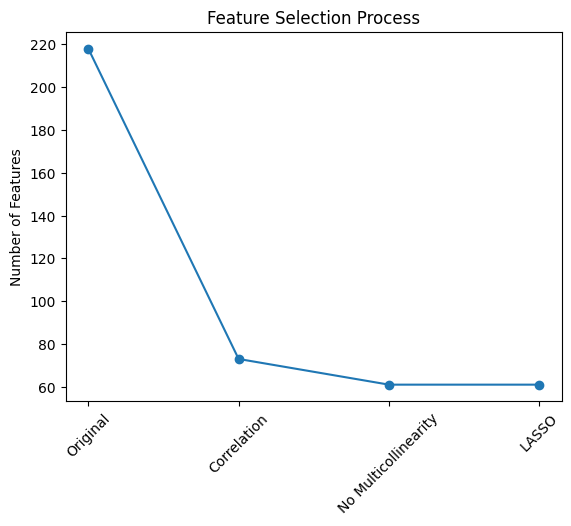

In [11]:
import matplotlib.pyplot as plt
stages = ["Original",
          "Correlation",
          "No Multicollinearity",
          "LASSO"]
dims = [
    X.shape[1],
    X_corr.shape[1],
    X_uncorr.shape[1],
    X_final.shape[1]
]
plt.plot(stages, dims, marker='o')
plt.ylabel("Number of Features")
plt.title("Feature Selection Process")
plt.xticks(rotation=45)
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (52292, 61)
Test: (13074, 61)


In [14]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    )

    # SVM 和 Gradient Boosting 已注释
}

In [15]:
results = []
roc_data = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_score)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    results.append([
        name,
        acc,
        prec,
        rec,
        f1,
        specificity,
        auc_score
    ])

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_data[name] = (fpr, tpr, auc_score)

results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall (Sensitivity)",
    "F1-score",
    "Specificity",
    "AUROC"
])

results_df.sort_values("AUROC", ascending=False)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training AdaBoost...


,Model,Accuracy,Precision,Recall (Sensitivity),F1-score,Specificity,AUROC
2,Random Forest,0.930702,0.839286,0.248677,0.383673,0.995477,0.906665
3,AdaBoost,0.929019,0.685252,0.335979,0.450888,0.985343,0.898906
0,Logistic Regression,0.930549,0.708487,0.338624,0.458234,0.986767,0.894248
1,Decision Tree,0.925272,0.650096,0.299824,0.410380,0.984673,0.824089


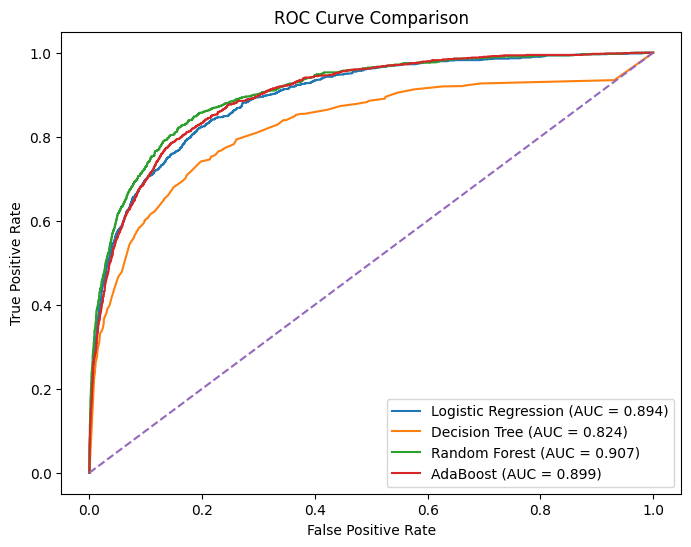

In [16]:
plt.figure(figsize=(8,6))

for name in roc_data:
    fpr, tpr, auc_score = roc_data[name]
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()